In [43]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [45]:
X , y = make_circles(n_samples= 400, noise = 0.2 , random_state = 42)

<Axes: >

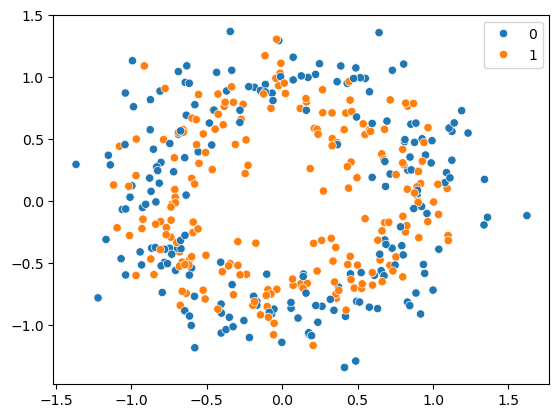

In [47]:
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)

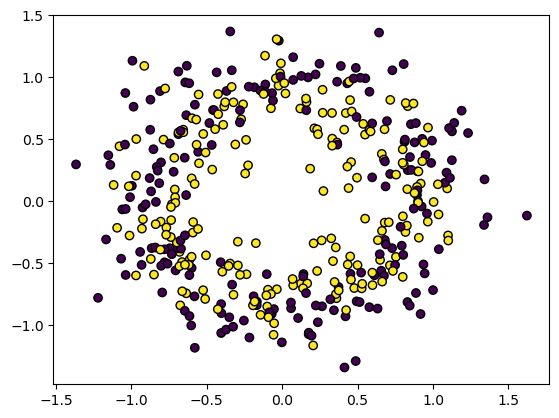

In [48]:
plt.scatter(X[:, 0], X[:, 1], c = y, edgecolor = 'k')

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20)

In [35]:
model = Sequential()
model.add(Dense(200, input_dim = 2, activation = 'relu'))
model.add(Dense(1,  activation = 'sigmoid'))          

In [37]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [39]:
history = model.fit(X_train, y_train, validation_data= (X_test, y_test), epochs = 500, verbose = 1)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4933 - loss: 0.6919 - val_accuracy: 0.6000 - val_loss: 0.6902
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5333 - loss: 0.6875 - val_accuracy: 0.6000 - val_loss: 0.6899
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5187 - loss: 0.6865 - val_accuracy: 0.5125 - val_loss: 0.6919
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5254 - loss: 0.6855 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5567 - loss: 0.6838 - val_accuracy: 0.5125 - val_loss: 0.6940
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6297 - loss: 0.6805 - val_accuracy: 0.4750 - val_loss: 0.6950
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5969 - loss: 0.6861 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6129 - loss: 0.6822 - val_accuracy: 0.5250 

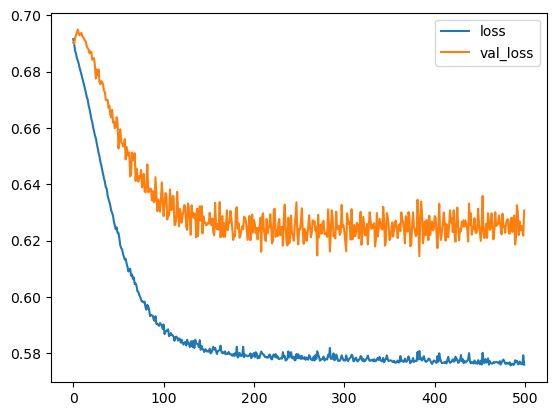

In [41]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

In [51]:
callback = EarlyStopping(monitor='val_loss' , min_delta= 0.00001 , patience= 20 , verbose = 1 , mode = 'auto', baseline = None, restore_best_weights=False)

In [53]:
history_early_stopping = model.fit(X_train, y_train, validation_data= (X_test, y_test), epochs = 500, callbacks= callback)
                                   

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6585 - loss: 0.6045 - val_accuracy: 0.5875 - val_loss: 0.6341
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6999 - loss: 0.5694 - val_accuracy: 0.5875 - val_loss: 0.6229
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7061 - loss: 0.5486 - val_accuracy: 0.5750 - val_loss: 0.6207
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6798 - loss: 0.5961 - val_accuracy: 0.5875 - val_loss: 0.6274
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6998 - loss: 0.5507 - val_accuracy: 0.5625 - val_loss: 0.6243
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6535 - loss: 0.5947 - val_accuracy: 0.5750 - val_loss: 0.6261
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6919 - loss: 0.5550 - val_accuracy: 0.5750 - val_loss: 0.6269
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6619 - loss: 0.5750 - val_accuracy: 0.5875

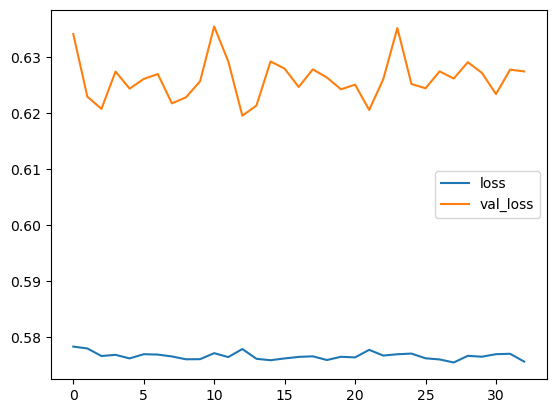

In [55]:
plt.plot(history_early_stopping.history['loss'], label = 'loss')
plt.plot(history_early_stopping.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()